Learning Data Handling in AIML


In [24]:
!pip install kaggle


In [25]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [26]:
!kaggle competitions download -c titanic

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 121MB/s]


In [27]:
#extracting zip file

In [28]:
import zipfile
dataset= '/content/titanic.zip'

with zipfile.ZipFile(dataset,'r') as zip_ref:
  zip_ref.extractall()
  print('extraction complete')

extraction complete


In [29]:
import pandas as pd

In [30]:
titanic = pd.read_csv('/content/train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Handling missing values

In [31]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


to fill the missing values we use simple statistics: CENTRAL TENDENCIES, i.e:

1. mean
2. median
3. mode

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-34-3306082441.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['Age'])


<Axes: xlabel='Age', ylabel='Density'>

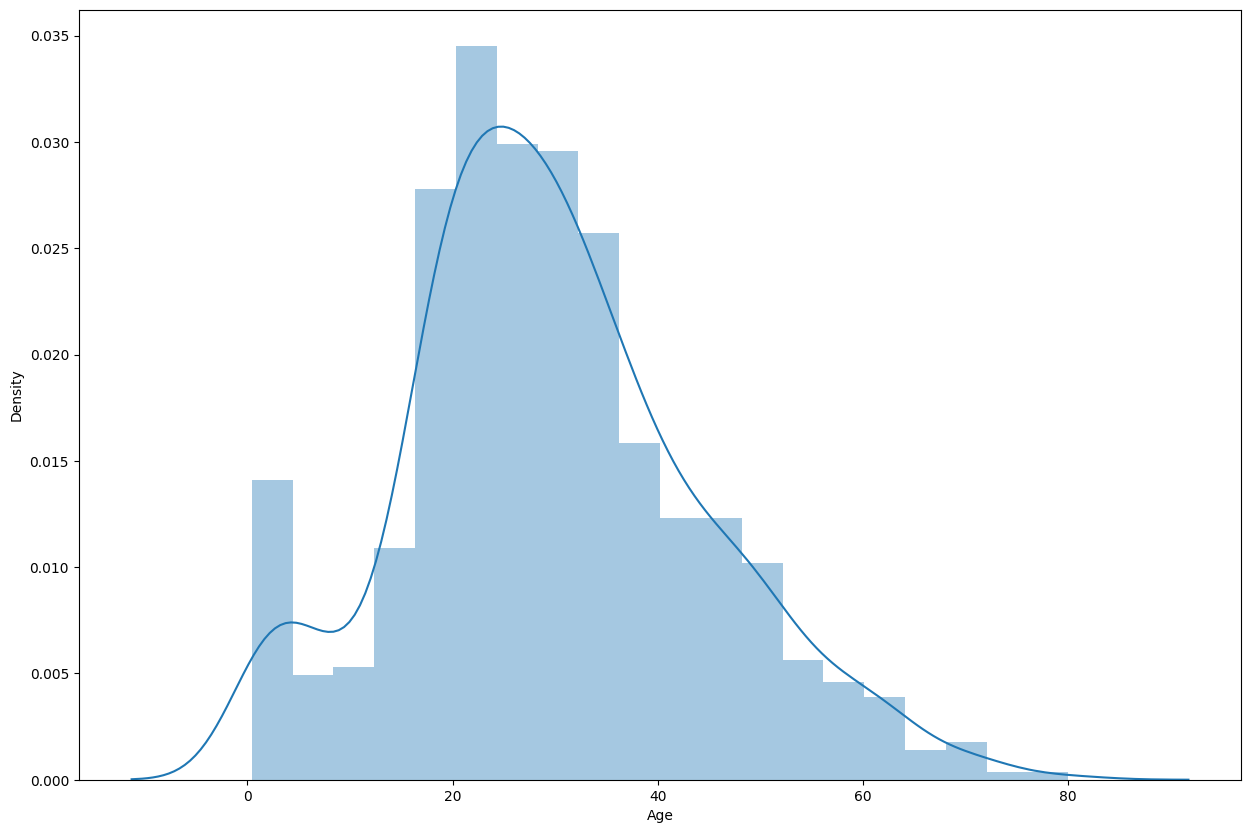

In [34]:
fig, ax= plt.subplots(figsize=(15,10))
sns.distplot(titanic['Age'])


replacing the missing values with median value

In [36]:
titanic['Age'].fillna(titanic['Age'].median(),inplace=True)
print('done')

done


/tmp/ipython-input-36-45030381.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(),inplace=True)


In [37]:
titanic['Age'].isnull().sum()

np.int64(0)

In [43]:
titanic.isnull().sum()
titanic.shape

(202, 12)

This method is known as Imputation
There is another method called Dropping method where we skip the NaN coloumns

In [44]:
titanic = titanic.dropna(how='any')

In [45]:
titanic.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


When the number of data in dataset is huge, then we can use dropping methods